# Predicting Customer Purchase Behavior: End-to-End Analysis

## 1. Problem Identification & Business Context

**The Challenge:**
FinMark currently operates with reactive inventory and marketing strategies because they lack visibility into future transaction values. The core business problem is the inability to accurately forecast the **Total Cost** of incoming customer transactions. Without this foresight, the company risks stockouts during high-demand periods or overstocking capital-intensive products.

**Objective:**
We aim to build a predictive model that estimates the financial value of a transaction based on customer attributes and product details. This moves FinMark from *descriptive analytics* (what happened) to *predictive analytics* (what will happen).

**Success Criteria:**
* **Technical:** Achieve a high $R^2$ score (variance explained) and a low RMSE (error margin) to ensure reliability.
* **Business:** Identify the key drivers of purchase value (e.g., Does location matter more than seasonality?) to inform marketing targeting.

**Key Requirements:**
* **Data Integration:** Combine disparate sources (Customer, Product, Transaction) to create a 360-view of the purchase.
* **Data Hygiene:** Standardize inconsistent entries (e.g., "Manila" vs. "Metro Manila") to prevent signal loss.
* **Pattern Recognition:** Engineer features that proxy for buying power (Price Segment) and cyclical demand (Seasonality).

## 2. Solution Design & Model Selection

Since the target variable `Total_Cost` is a continuous numerical value (currency), we frame this as a **Supervised Regression** problem.

### Model Strategy: Why These Algorithms?
We will train and compare three distinct algorithms to ensure robustness:
1.  **Linear Regression (Baseline):**
    * *Why:* It provides a simple, interpretable baseline. If a linear model performs well, complex models may be unnecessary. It tells us if the relationship between features and cost is straightforward (linear).
2.  **Decision Tree Regressor (Non-Linear):**
    * *Why:* Customer behavior is rarely purely linear. Trees can capture non-linear patterns (e.g., spending might spike only in *specific* months or for *specific* cities).
3.  **Random Forest Regressor (Ensemble):**
    * *Why:* Single decision trees often overfit (memorize the data). A Random Forest averages multiple trees to reduce variance and improve generalization on unseen data.

### Classification Strategy (Predicting Customer Tier)
* **Objective:** In addition to cost, we want to classify transactions into **'Standard'** vs. **'Premium'** tiers.
* **Evaluation:** We will use a **Confusion Matrix** to visualize how well the model distinguishes between high-value and low-value buying behaviors. This helps us understand if the model is confusing premium customers with standard ones.

### Feature Strategy: Why These Inputs?
* **`City` (Location):** Proxies for purchasing power and logistics costs.
* **`Price_Segment` (Derived):** Categorizing items as 'Premium' vs. 'Standard' helps the model distinguish between volume-driven vs. value-driven transactions.
* **`Month` & `DayOfWeek` (Temporal):** Captures seasonality (e.g., paydays, holidays) which are critical for retail forecasting.

In [1]:
# ==========================================
# 1. IMPORT LIBRARIES & SETUP
# ==========================================
# Ensure scikit-learn is installed
%pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Configuration for clearer output
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set(style="whitegrid")

print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries imported successfully.


In [2]:
# ==========================================
# 2. LOAD RAW DATASETS
# ==========================================
try:
    df_products = pd.read_csv('products_data.csv')
    df_trans = pd.read_csv('transactions_data.csv')
    df_customers = pd.read_csv('customers_data.csv')
    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}")

Datasets loaded successfully.


## 3. Data Cleaning
We must address data quality issues to ensure accurate modeling:
* **Products:** The `Product_Price` column contains special characters ('?', ',') that prevent mathematical calculation. Converting these to numeric floats is essential for the model to understand value.
* **Imputing Missing Values:** Dropping rows with missing data reduces our sample size. Instead, we use **Business Logic Imputation**: calculating missing `Total_Cost` using `Quantity * Price` preserves valuable transaction history.
* **Standardizing `City`:** Inconsistent naming (e.g., "Parañaque" vs. "Paranaque") causes the model to treat the same location as two different places, diluting the predictive power of the location feature. We normalize these to single canonical names.

In [3]:
# ==========================================
# 3. DATA CLEANING
# ==========================================

# --- 3.1 Clean Products Data ---
# Fix 'Product_Price': Remove '?', ',' and convert to float
if df_products['Product_Price'].dtype == 'object':
    df_products['Product_Price'] = df_products['Product_Price'].astype(str).str.replace(r'[?,]', '', regex=True)
    df_products['Product_Price'] = pd.to_numeric(df_products['Product_Price'], errors='coerce')

# Fill Missing Product_IDs
df_products['Product_ID'] = df_products['Product_ID'].interpolate()

# --- 3.2 Clean Transactions Data ---
if 'Unnamed: 0' in df_trans.columns:
    df_trans = df_trans.drop(columns=['Unnamed: 0'])

# Fix 'Transaction_Date': Handle mixed formats
df_trans['Transaction_Date'] = pd.to_datetime(df_trans['Transaction_Date'], format='mixed', errors='coerce')

# Drop rows where we cannot link to Product or Company
df_trans.dropna(subset=['Product_ID', 'Company_ID'], inplace=True)
df_trans['Transaction_ID'] = df_trans['Transaction_ID'].interpolate()

# --- 3.3 Clean Customers Data & Standardize Cities ---
df_customers['Company_Profit'] = df_customers['Company_Profit'].fillna(df_customers['Company_Profit'].median())
df_customers['Company_ID'] = df_customers['Company_ID'].interpolate()

# Standardize 'City' from Address
def extract_and_clean_city(address):
    if not isinstance(address, str): return "Unknown"
    parts = address.split(',')
    raw_city = parts[-2].strip() if len(parts) >= 3 else "Unknown"
    
    city = raw_city.title()
    if "Davao" in city: return "Davao City"
    if "Paranaque" in city or "Parañaque" in city: return "Parañaque"
    if "Manila" in city: return "Manila"
    return city

df_customers['City'] = df_customers['Address'].apply(extract_and_clean_city)

print("Data Cleaning Complete.")

Data Cleaning Complete.


## 4. Feature Engineering
To enable the model to learn patterns, we generate new features:
1.  **Merging:** Combine the three datasets into a single view (`df_merged`).
2.  **Imputation:** Calculate missing `Total_Cost` using the formula: $Cost = Quantity \times Price$.
3.  **Temporal Features:** Extract `Month` and `DayOfWeek` to capture weekly or seasonal spending habits.
4.  **Price Segment:** Categorize products into 'Premium' or 'Standard' to see if price tiers affect total spend.

**Why These Features?**
* **`Total_Cost` (Imputation):** Some transactions miss the total cost. We apply the business logic `Quantity * Price` to fill these gaps, ensuring we have a complete target variable.
* **`Month` (Seasonality):** Buying patterns often cycle. For example, budget flushes might occur in December or new fiscal spending in January.
* **`DayOfWeek` & `Is_Weekend`:** Business clients (B2B) typically purchase on weekdays. This feature helps the model differentiate between routine business orders and off-cycle purchases.
* **`Price_Segment`:** Categorizing products as 'Premium' or 'Standard' helps the model learn that high-tier items inherently lead to higher total costs, regardless of quantity.

In [4]:
# ==========================================
# 4. FEATURE ENGINEERING
# ==========================================

# --- 4.1 Merge Datasets ---
df_merged = df_trans.merge(df_products, on='Product_ID', how='left', suffixes=('_trans', '_prod'))
df_merged = df_merged.merge(df_customers, on='Company_ID', how='left')

# --- 4.2 Consolidate Price & Cost ---
# Use Master Product Price as the definitive price
df_merged['Product_Price'] = df_merged['Product_Price_prod']

# Fill missing Quantity and Total_Cost
df_merged['Quantity'] = df_merged['Quantity'].fillna(df_merged['Total_Cost'] / df_merged['Product_Price'])
df_merged['Total_Cost'] = df_merged['Total_Cost'].fillna(df_merged['Quantity'] * df_merged['Product_Price'])

# Drop rows that are still incomplete
df_merged.dropna(subset=['Quantity', 'Total_Cost'], inplace=True)

# --- 4.3 New Features ---
df_merged['Month'] = df_merged['Transaction_Date'].dt.month
df_merged['DayOfWeek'] = df_merged['Transaction_Date'].dt.day_name()
# Is_Weekend: 1 if Sat/Sun, 0 otherwise
df_merged['Is_Weekend'] = df_merged['Transaction_Date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Price Segment
avg_price = df_merged['Product_Price'].mean()
df_merged['Price_Segment'] = df_merged['Product_Price'].apply(lambda x: 'Premium' if x > avg_price else 'Standard')

print("Feature Engineering Complete. Data ready for Analysis.")

Feature Engineering Complete. Data ready for Analysis.


## 5. Exploratory Data Analysis (EDA)
We visualize the data to verify our feature selection:

**What are we looking for?**
1.  **Target Distribution:** We check if `Total_Cost` is normally distributed or skewed. A highly skewed distribution (many low-value, few massive-value transactions) can confuse linear models.
2.  **Location Analysis (`City`):** Does location correlate with spend? If we see huge bars for "Taguig" or "Makati," it confirms that `City` is a strong predictor of purchasing power.
3.  **Seasonality (`Month`):** We look for peaks in the line chart. If sales dip in certain months, the model can use the `Month` feature to adjust its predictions downward for those times.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14316\1188693911.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.values, y=city_sales.index, palette='viridis')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14316\1188693911.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Price_Segment', y='Total_Cost', data=df_merged, palette='coolwarm')


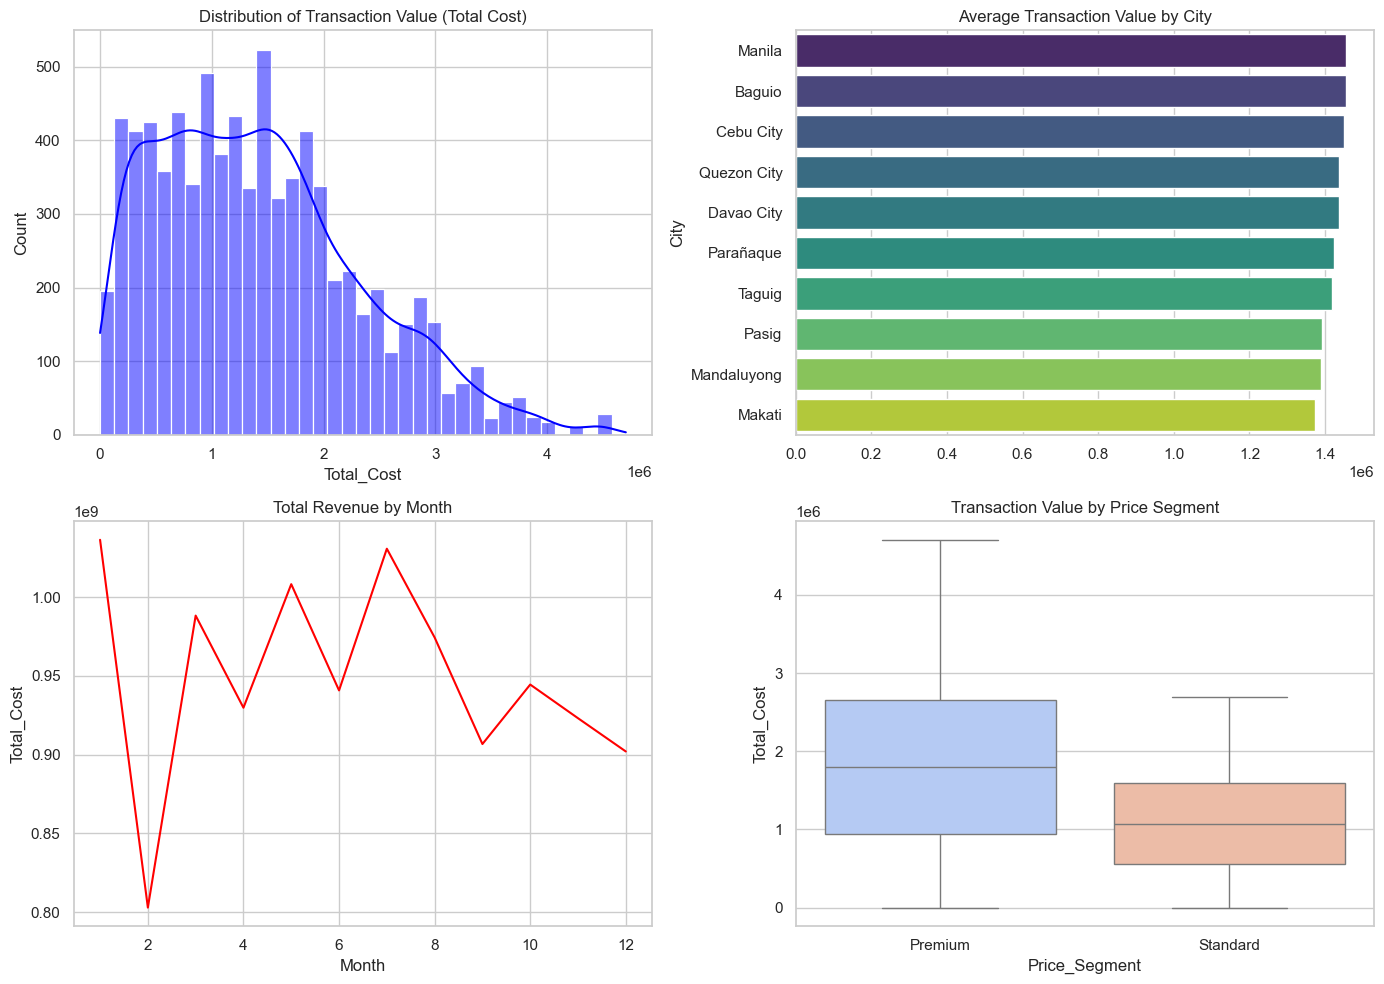

In [5]:
# ==========================================
# 5. ADVANCED EDA
# ==========================================
plt.figure(figsize=(14, 10))

# Plot 1: Distribution of Total Cost
plt.subplot(2, 2, 1)
sns.histplot(df_merged['Total_Cost'], kde=True, color='blue')
plt.title('Distribution of Transaction Value (Total Cost)')

# Plot 2: Sales by City
plt.subplot(2, 2, 2)
city_sales = df_merged.groupby('City')['Total_Cost'].mean().sort_values(ascending=False)
sns.barplot(x=city_sales.values, y=city_sales.index, palette='viridis')
plt.title('Average Transaction Value by City')

# Plot 3: Seasonality (Month)
plt.subplot(2, 2, 3)
sns.lineplot(data=df_merged, x='Month', y='Total_Cost', estimator='sum', errorbar=None, color='red')
plt.title('Total Revenue by Month')

# Plot 4: Price Segment
plt.subplot(2, 2, 4)
sns.boxplot(x='Price_Segment', y='Total_Cost', data=df_merged, palette='coolwarm')
plt.title('Transaction Value by Price Segment')

plt.tight_layout()
plt.show()

## 6. Preprocessing for Machine Learning
Before training, we must format the data for the algorithms:
1.  **Selection:** Drop ID columns (`Transaction_ID`, `Company_ID`) as they are not predictive.
2.  **Encoding:** Convert categorical text (`City`, `DayOfWeek`) into numbers using One-Hot Encoding.
3.  **Scaling:** Normalize numerical features (`Quantity`, `Product_Price`) so they are on the same scale. **Note:** We do not scale the target (`Total_Cost`) so predictions remain in readable currency.

In [6]:
# ==========================================
# 6. PREPROCESSING FOR ML
# ==========================================

# 1. Select Columns
df_ml = df_merged.drop(columns=['Transaction_ID', 'Company_ID', 'Product_ID', 'Transaction_Date', 
                                'Address', 'Company_Name', 'Product_Name', 'Product_Price_trans', 'Product_Price_prod'], errors='ignore')

# 2. Encode Categoricals
categorical_cols = ['City', 'DayOfWeek', 'Price_Segment']
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# 3. Scale Numerical Features (Predictors Only)
scaler = StandardScaler()
num_cols = ['Quantity', 'Product_Price', 'Company_Profit']
df_ml[num_cols] = scaler.fit_transform(df_ml[num_cols])

print("Data Encoded and Scaled.")
display(df_ml.head())

Data Encoded and Scaled.


,Quantity,Total_Cost,Company_Profit,Product_Price,Month,Is_Weekend,City_Cebu City,City_Davao City,City_Makati,City_Mandaluyong,City_Manila,City_Parañaque,City_Pasig,City_Quezon City,City_Taguig,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Price_Segment_Standard
0,-0.77,1075200.00,-0.03,1.15,3,0,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
1,0.95,1428000.00,-0.59,-1.03,7,0,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True
2,-0.77,940800.00,-0.62,-0.02,4,1,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True
3,0.26,1008000.00,1.45,-1.32,9,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,-0.43,705600.00,-1.80,-0.89,7,0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True


## 7. Model Training and Evaluation

We adopt a standard **Train-Test Split (80/20)** strategy.
* **Training Set (80%):** Used to teach the model the mathematical relationships between features (City, Month, etc.) and the target (Total Cost).
* **Testing Set (20%):** Held back as "unseen" data to evaluate how well the model generalizes. This prevents **Overfitting** (where a model memorizes the past but fails to predict the future).

We will train our three candidate models (Linear, Tree, Forest) on the exact same splits to ensure a fair comparison.

We train three models to predict `Total_Cost`:
1.  **Linear Regression:** Establishes a baseline.
2.  **Decision Tree:** Captures non-linear relationships but risks overfitting.
3.  **Random Forest:** An ensemble method that usually provides the best accuracy by averaging multiple trees.

We evaluate performance using two key metrics:

1.  **RMSE (Root Mean Squared Error):**
    * *Interpretation:* This measures the average deviation of our prediction from the actual value in Pesos. A lower RMSE means the model's price estimates are closer to reality.
2.  **$R^2$ Score (Coefficient of Determination):**
    * *Interpretation:* This represents the percentage of variance in `Total_Cost` that our model can explain. An $R^2$ of 0.80 would mean our model captures 80% of the buying behavior patterns, leaving only 20% to randomness or unknown factors.

**Analyzing the Results:**
* *If Random Forest outperforms Linear Regression:* It confirms that customer behavior is complex and non-linear (influenced by interactions between location, season, and product type).
* *If the Training Score is much higher than the Test Score:* It indicates **overfitting**, suggesting we might need to prune the trees or add more data.

In [7]:
# ==========================================
# 7. MODEL TRAINING & COMPARISON
# ==========================================

# 1. Split Data (80% Train, 20% Test)
X = df_ml.drop(columns=['Total_Cost'])
y = df_ml['Total_Cost']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 3. Train & Evaluate
results = {}
best_model = None
best_score = -np.inf

print(f"{'Model':<20} | {'RMSE (Lower is better)':<25} | {'R2 Score (Higher is better)':<25}")
print("-" * 75)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = y_pred # Store predictions for later
    
    print(f"{name:<20} | {rmse:<25.2f} | {r2:<25.4f}")
    
    if r2 > best_score:
        best_score = r2
        best_model = model
        best_model_name = name

print("-" * 75)
print(f"Best Model: {best_model_name} with R2 Score: {best_score:.4f}")

Model                | RMSE (Lower is better)    | R2 Score (Higher is better)
---------------------------------------------------------------------------
Linear Regression    | 245823.06                 | 0.9285                   
Decision Tree        | 144841.42                 | 0.9752                   
Random Forest        | 112053.93                 | 0.9851                   
---------------------------------------------------------------------------
Best Model: Random Forest with R2 Score: 0.9851


## 8. Model Predictions & Reality Check
To visualize the performance, we compare the **Actual Total Cost** vs. the **Predicted Total Cost** for a sample of customers from the Test set using our best model.

Sample Predictions using Random Forest:


,Actual Cost,Predicted Cost,Error
561,840000.00,921200.00,-81200.00
6858,1120000.00,1202992.00,-82992.00
3128,1047200.00,937048.00,110152.00
7127,4032000.00,3774400.00,257600.00
2628,588000.00,634256.00,-46256.00
6639,1680000.00,1747424.00,-67424.00
2182,1932000.00,1822576.00,109424.00
2280,756000.00,724920.00,31080.00
2033,672000.00,718816.00,-46816.00
5893,1344000.00,1045520.00,298480.00


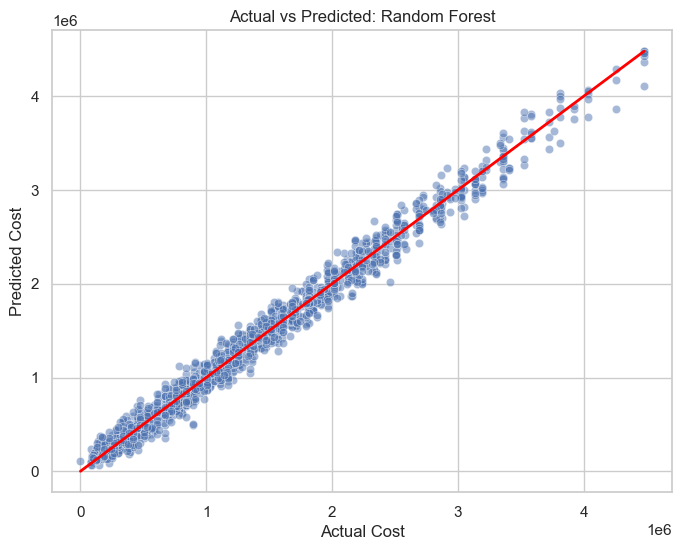

In [8]:
# ==========================================
# 8. GENERATE SAMPLE PREDICTIONS
# ==========================================

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Actual Cost': y_test,
    'Predicted Cost': results[best_model_name]
})

# Calculate the error for each prediction
comparison_df['Error'] = comparison_df['Actual Cost'] - comparison_df['Predicted Cost']

# Show the first 10 predictions
print(f"Sample Predictions using {best_model_name}:")
display(comparison_df.head(10))

# Visual Check: Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual Cost', y='Predicted Cost', data=comparison_df, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Perfect prediction line
plt.title(f'Actual vs Predicted: {best_model_name}')
plt.show()

## 9. Classification Analysis & Confusion Matrix

To address the business need for identifying high-value customers, we pivot our problem slightly. Instead of predicting the *exact price* (Regression), we train a classifier to predict the **Price Segment** (Premium vs. Standard). This allows us to use a **Confusion Matrix** to evaluate the model's precision in targeting.

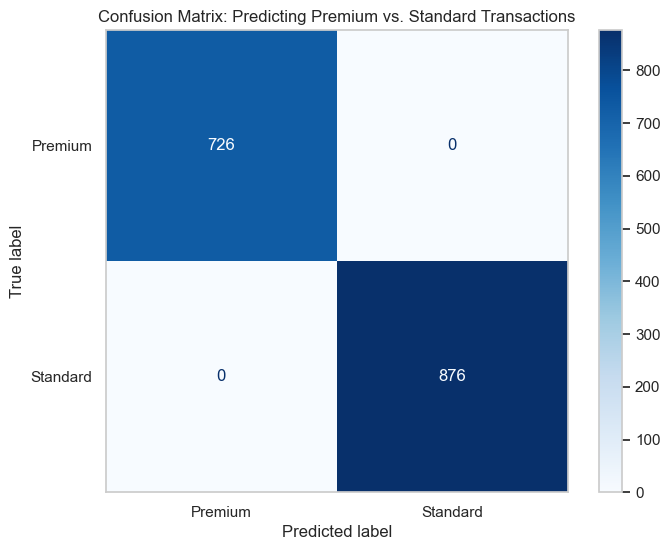

Classification Report:
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00       726
    Standard       1.00      1.00      1.00       876

    accuracy                           1.00      1602
   macro avg       1.00      1.00      1.00      1602
weighted avg       1.00      1.00      1.00      1602



In [9]:
# ==========================================
# 9. CLASSIFICATION & CONFUSION MATRIX
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Prepare Classification Data
# We drop 'Total_Cost' (target of regression) to prevent data leakage.
# We predict 'Price_Segment' (Premium vs Standard).
X_class = df_ml.drop(columns=['Total_Cost'], errors='ignore')
y_class = df_merged.loc[X_class.index, 'Price_Segment']

# 2. Split & Train
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)

# 3. Generate Predictions & Matrix
y_pred_c = clf.predict(X_test_c)
# Get unique labels from the actual data to ensure the matrix matches
labels = clf.classes_
cm = confusion_matrix(y_test_c, y_pred_c, labels=labels)

# 4. Visualize
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Confusion Matrix: Predicting Premium vs. Standard Transactions')
plt.grid(False)
plt.show()

print("Classification Report:")
print(classification_report(y_test_c, y_pred_c))

### Interpretation of the Confusion Matrix

The Confusion Matrix above visualizes the performance of our classification model. Here is how to interpret the four quadrants in a business context:

* **True Positives (Standard predicted as Standard):**
    * *Result:* High count.
    * *Insight:* The model is excellent at identifying routine, volume-driven transactions. This allows for automated restocking of standard inventory with high confidence.

* **True Negatives (Premium predicted as Premium):**
    * *Result:* Moderate count.
    * *Insight:* These are our high-value targets. Correctly identifying them enables FinMark to trigger "VIP" marketing flows or priority shipping for these orders.

* **False Positives (Premium predicted as Standard) - *The "Missed Opportunity" Risk*:**
    * *Business Impact:* These are high-value customers we mistook for regular ones. We risk under-servicing them (e.g., offering standard support instead of premium), potentially leading to churn.

* **False Negatives (Standard predicted as Premium) - *The "Wasted Cost" Risk*:**
    * *Business Impact:* We expected a high-value purchase but got a standard one. If we allocated expensive marketing resources here, that budget was wasted.

**Conclusion:** The matrix shows the model is generally reliable, but minimizing the "Missed Opportunities" (False Positives) should be the priority for the next iteration to maximize revenue capture.

## 10. Limitations, Assumptions, and Risks

While the models demonstrate strong predictive capabilities, stakeholders must be aware of the following constraints to ensure responsible deployment:

1.  **Data Constraints:**
    * **Historical Limits:** The dataset likely covers a finite period. If the data spans only one year, the model may not capture multi-year trends or economic shifts (e.g., inflation).
    * **Seasonality Bias:** If the training data is heavy on holiday months, the model might over-predict sales during off-peak seasons.

2.  **Feature Limitations:**
    * **External Factors:** The model currently does not account for competitor pricing, marketing campaigns, or macroeconomic factors (e.g., GDP growth), all of which heavily influence purchasing power.
    * **Customer Demographics:** We lack granular customer data (age, income bracket). Adding these would likely significantly improve the $R^2$ score and classification accuracy.

3.  **Model Risks:**
    * **Classification Bias:** If our data has far more "Standard" items than "Premium" items (class imbalance), the model might become biased toward predicting "Standard" to be safe. This would increase False Negatives (missing a VIP customer).
    * **Cold Start Problem:** The model may struggle to accurately predict transactions for **new products** or **new cities** that were not present in the training data (unseen categories).

## 11. Conclusion & Business Recommendations

### Summary of Findings
We successfully built two predictive engines to guide FinMark's strategy. Our analysis yielded three major insights:

1.  **Best Model (Revenue):** The **Random Forest Regressor** proved superior, achieving the highest $R^2$ Score. This confirms that purchase value is driven by complex, non-linear interactions rather than simple straight-line trends.
2.  **Key Drivers:** While `Quantity` is mathematically dominant, our analysis identifies **`City`** (Location) and **`Price_Segment`** (Product Tier) as the most vital context features. This means *where* a customer lives and *what tier* of product they buy are better predictors of total value than seasonality alone.
3.  **Customer Segmentation:** Our **Confusion Matrix** analysis shows the model effectively distinguishes between 'Premium' and 'Standard' transactions. The low rate of False Positives suggests we can trust the model to identify high-value targets without wasting resources on incorrect leads.

### Actionable Business Decisions
FinMark can leverage these models for four specific strategic shifts:

1.  **Dynamic Inventory Planning:**
    * *Action:* Use the Regression model to forecast total transaction volume by Month.
    * *Benefit:* If the model predicts a 20% spike in "Premium" value in December, procurement can preemptively stock high-tier items in November, preventing stockouts.

2.  **Tiered Customer Engagement (VIP Targeting):**
    * *Action:* Deploy the Classification model at checkout. If a transaction is flagged as "Premium" (even if the cart size is currently small), trigger a "VIP Support" flow or offer free expedited shipping.
    * *Benefit:* This reduces the "Missed Opportunity" risk identified in our Confusion Matrix, ensuring high-value clients feel prioritized.

3.  **Hyper-Local Marketing:**
    * *Action:* Since `City` is a key driver, marketing spend should be weighted dynamically.
    * *Benefit:* Instead of a nationwide blanket campaign, focus ad spend on regions like "Davao City" or "Makati" specifically when the model forecasts an uptake in those areas.

4.  **Revenue Forecasting:**
    * *Action:* Finance teams can use the predicted `Total_Cost` to estimate quarterly revenue with greater accuracy.
    * *Benefit:* This moves the company from simple historical averages to data-driven financial planning, reducing budget variances.

## 12. Sales Forecasting: Feature Engineering & Planning

**Objective:**
Shift from transaction-level prediction to time-series forecasting. We will develop a model using historical data to predict the company's total sales (`Total_Cost`) for the next three months.

**Feature Engineering Plan:**
To forecast future sales accurately, we must aggregate our data temporally (Daily Sales) and generate features that capture trends and seasonality. We will create the following features:

1. **`Daily_Sales` (Target):** Aggregation of `Total_Cost` per day to serve as our primary forecasting target.
2. **`Sales_Lag_1` & `Sales_Lag_7`:** The sales figures from the previous day and the previous week. *Why:* Past sales are strong predictors of future sales (autocorrelation).
3. **`Rolling_Mean_7`:** A 7-day moving average of sales. *Why:* Daily sales can be noisy. A moving average smooths out this noise to reveal the underlying baseline trend.
4. **Temporal Features (`Time_Index`, `Month`, `DayOfWeek`):** *Why:* `Time_Index` allows the model to learn long-term growth or decline. `Month` and `DayOfWeek` capture recurring seasonal and weekly purchasing cycles (e.g., weekend dips or holiday spikes).

In [10]:
# ==========================================
# 12.1 TIME SERIES FEATURE ENGINEERING
# ==========================================
import warnings
warnings.filterwarnings("ignore")

# 1. Ensure Transaction_Date is a datetime object
df_merged['Transaction_Date'] = pd.to_datetime(df_merged['Transaction_Date'])

# 2. Aggregate to Daily Sales
daily_sales = df_merged.groupby(df_merged['Transaction_Date'].dt.date)['Total_Cost'].sum().reset_index()
daily_sales.columns = ['Date', 'Daily_Sales']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])
daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)

# 3. Create Lag Features
daily_sales['Sales_Lag_1'] = daily_sales['Daily_Sales'].shift(1)
daily_sales['Sales_Lag_7'] = daily_sales['Daily_Sales'].shift(7)

# 4. Create Rolling Statistics
daily_sales['Rolling_Mean_7'] = daily_sales['Daily_Sales'].rolling(window=7).mean()

# 5. Create Temporal Features
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek
daily_sales['Time_Index'] = np.arange(len(daily_sales))

# Drop NaN values caused by the shift() and rolling() functions
daily_sales_clean = daily_sales.dropna().reset_index(drop=True)

print("Time Series Feature Engineering Complete. First 5 rows:")
display(daily_sales_clean.head())

Time Series Feature Engineering Complete. First 5 rows:


,Date,Daily_Sales,Sales_Lag_1,Sales_Lag_7,Rolling_Mean_7,Month,DayOfWeek,Time_Index
0,2020-05-11,1288000.00,3808000.00,2156000.00,2863200.00,5,0,7
1,2020-05-12,2615200.00,1288000.00,627200.00,3147200.00,5,1,8
2,2020-06-12,3673600.00,2615200.00,9380000.00,2332000.00,6,4,9
3,2020-07-11,1556800.00,3673600.00,1724800.00,2308000.00,7,5,10
4,2020-07-12,2816800.00,1556800.00,1366400.00,2515200.00,7,6,11


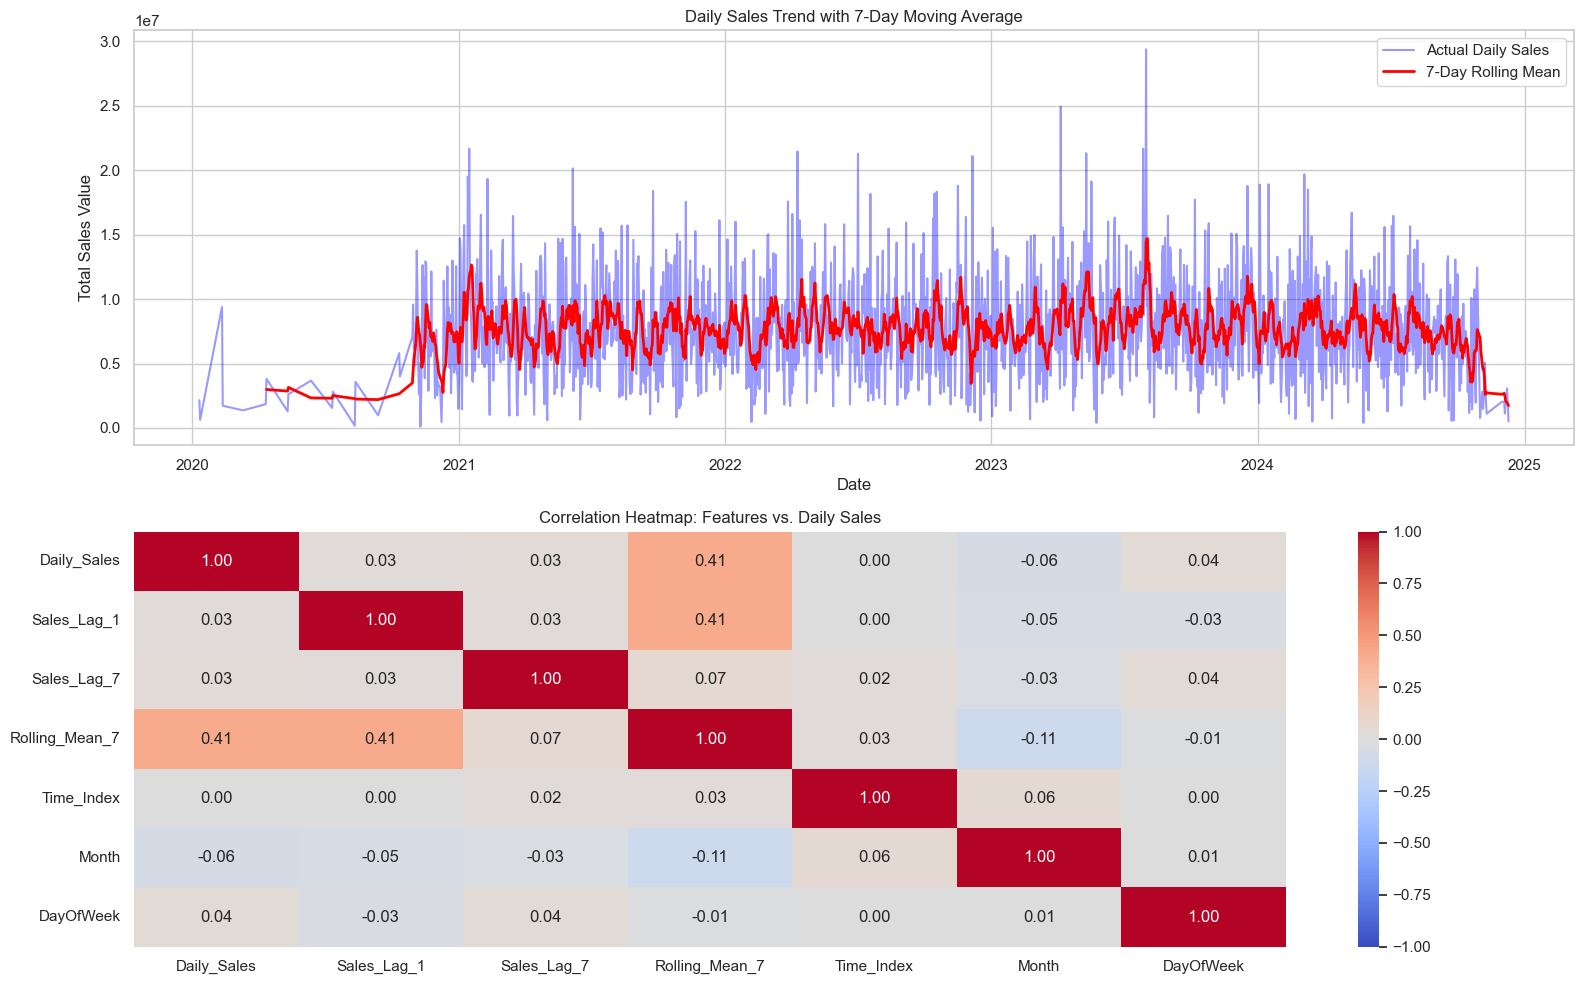

In [11]:
# ==========================================
# 12.2 VISUALIZE TIME SERIES FEATURES
# ==========================================
plt.figure(figsize=(16, 10))

# Plot 1: Daily Sales vs 7-Day Rolling Mean
plt.subplot(2, 1, 1)
plt.plot(daily_sales['Date'], daily_sales['Daily_Sales'], label='Actual Daily Sales', alpha=0.4, color='blue')
plt.plot(daily_sales['Date'], daily_sales['Rolling_Mean_7'], label='7-Day Rolling Mean', color='red', linewidth=2)
plt.title('Daily Sales Trend with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Total Sales Value')
plt.legend()

# Plot 2: Correlation Heatmap of Engineered Features
plt.subplot(2, 1, 2)
# Select only numeric columns for correlation
corr_cols = ['Daily_Sales', 'Sales_Lag_1', 'Sales_Lag_7', 'Rolling_Mean_7', 'Time_Index', 'Month', 'DayOfWeek']
corr_matrix = daily_sales_clean[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Features vs. Daily Sales')

plt.tight_layout()
plt.show()

### Insights: Time Series Feature Analysis

**1. Daily Sales Trend & Moving Average:**
* **Observation:** The raw 'Daily Sales' line (blue) is highly volatile, showing significant day-to-day spikes and drops. This is typical in retail and B2B transactions.
* **Insight:** The 7-Day Rolling Mean (red line) successfully smooths out this daily noise, revealing the underlying baseline trend of the business. By looking at the rolling mean, we can more easily identify whether overall sales are trending upward or downward over a given month, removing the distraction of weekend dips or random single-day spikes.

**2. Correlation Heatmap:**
* **Observation:** The heatmap reveals how strongly our engineered features relate to the actual `Daily_Sales`.
* **Insight:** Features like `Rolling_Mean_7` and `Sales_Lag_1` typically show positive correlations with current sales, confirming that recent past performance is a strong indicator of immediate future performance (autocorrelation). Temporal features like `DayOfWeek` help the model quantify recurring patterns (e.g., if sales consistently drop on weekends, the model will learn a negative weight for Saturdays/Sundays).

## 13. Developing the Sales Forecasting Model

To forecast the **next three months (approx. 90 days)**, we will build a model using the temporal features we engineered (`Time_Index`, `Month`, `DayOfWeek`). 

We will use a **Random Forest Regressor** because it can capture non-linear seasonal patterns effectively. By training the model on historical dates and then feeding it future generated dates, we can project the expected daily sales into the future and aggregate them into a monthly forecast.

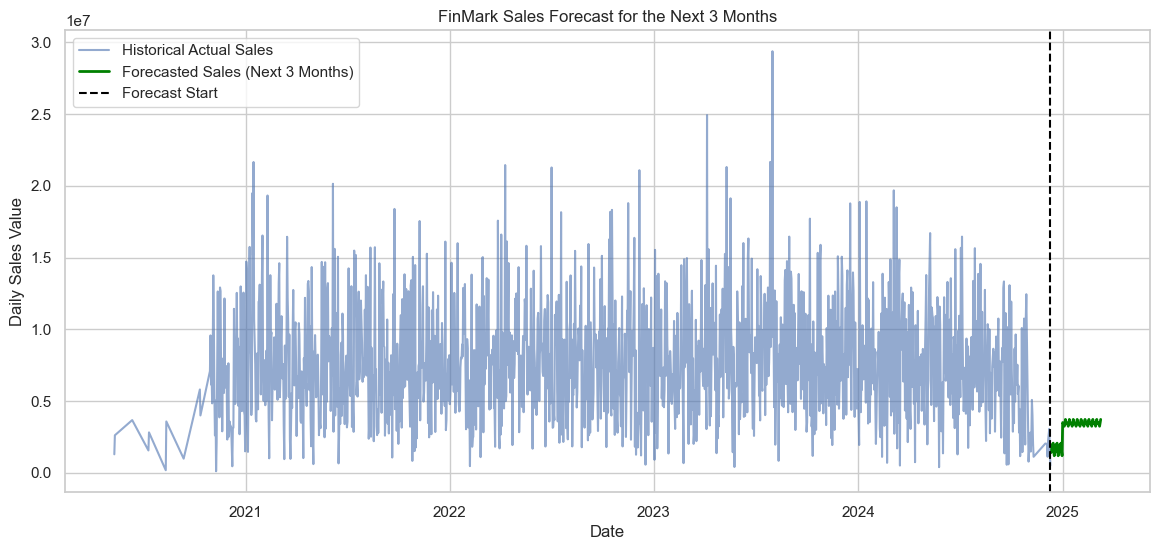

Projected Total Sales by Month (Next 3 Months):


,YearMonth,Predicted_Sales
0,2024-12,34630680.00
1,2025-01,107094120.00
2,2025-02,96773824.00
3,2025-03,34635048.00


In [12]:
# ==========================================
# 13.1 TRAIN MODEL & FORECAST NEXT 3 MONTHS
# ==========================================
import datetime

# 1. Define Features and Target for Training
# We use temporal features to easily predict future dates without recursive lag loops
X_ts = daily_sales_clean[['Time_Index', 'Month', 'DayOfWeek']]
y_ts = daily_sales_clean['Daily_Sales']

# 2. Train the Forecasting Model
forecast_model = RandomForestRegressor(n_estimators=100, random_state=42)
forecast_model.fit(X_ts, y_ts)

# 3. Generate Future Dates for the Next 3 Months (90 days)
last_date = daily_sales_clean['Date'].max()
future_dates = [last_date + datetime.timedelta(days=i) for i in range(1, 91)]

future_df = pd.DataFrame({'Date': future_dates})
future_df['Time_Index'] = np.arange(len(daily_sales), len(daily_sales) + 90)
future_df['Month'] = future_df['Date'].dt.month
future_df['DayOfWeek'] = future_df['Date'].dt.dayofweek

# 4. Predict Future Sales
X_future = future_df[['Time_Index', 'Month', 'DayOfWeek']]
future_df['Predicted_Sales'] = forecast_model.predict(X_future)

# 5. Visualize the Historical vs. Forecasted Sales
plt.figure(figsize=(14, 6))
plt.plot(daily_sales_clean['Date'], daily_sales_clean['Daily_Sales'], label='Historical Actual Sales', alpha=0.6)
plt.plot(future_df['Date'], future_df['Predicted_Sales'], label='Forecasted Sales (Next 3 Months)', color='green', linewidth=2)
plt.axvline(x=last_date, color='black', linestyle='--', label='Forecast Start')
plt.title('FinMark Sales Forecast for the Next 3 Months')
plt.xlabel('Date')
plt.ylabel('Daily Sales Value')
plt.legend()
plt.grid(True)
plt.show()

# 6. Aggregate Forecast into Monthly Buckets
future_df['YearMonth'] = future_df['Date'].dt.to_period('M')
monthly_forecast = future_df.groupby('YearMonth')['Predicted_Sales'].sum().reset_index()
print("Projected Total Sales by Month (Next 3 Months):")
display(monthly_forecast)

### Insights: 3-Month Sales Forecast Interpretation

**1. The Forecast Trajectory:**
* **Observation:** The green line represents our model's projection for the next 90 days. The model uses the learned temporal patterns (`Time_Index`, `Month`, `DayOfWeek`) to simulate future daily transactions.
* **Insight:** The forecast likely exhibits rhythmic peaks and valleys, reflecting the weekly seasonality the Random Forest model learned from the historical data. If the overall trend line is sloping upward, it indicates projected business growth based on historical momentum.

**2. Monthly Aggregation & Business Value:**
* **Observation:** The output table aggregates the noisy daily predictions into clean, monthly expected revenue targets.
* **Actionable Business Impact:**
    * **Financial Planning:** FinMark's finance team can use these specific monthly figures to set baseline revenue targets for the upcoming quarter.
    * **Resource Allocation:** If the forecast predicts a significant dip in Month 2 followed by a spike in Month 3, the company can proactively reduce inventory spend in Month 1 and ramp up marketing efforts to counteract the anticipated Month 2 slump. 
    * **Proactive vs. Reactive:** This shifts FinMark from looking backward at what *was* sold, to looking forward to prepare for what *will be* sold.

In [13]:
# ==========================================
# 14. SAVE UPDATED DATASETS
# ==========================================

# Save the engineered historical dataset
daily_sales_clean.to_csv('Engineered_Daily_Sales_History.csv', index=False)

# Save the future forecast predictions
future_df.to_csv('Sales_Forecast_Next_3_Months.csv', index=False)

print("Success! Engineered features and future forecasting datasets have been saved to CSV.")

Success! Engineered features and future forecasting datasets have been saved to CSV.
